# Модель Росса: набор параметров

Время до падения системы случайное и меняется от прогона к прогону
очень сильно, поэтому пяти прогонов для сравнения с теорией мало.
Здесь моделирование повторяется по 50 раз для разного числа машин,
разного резерва и одного или двух ремонтников.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
@isdefined(RossModel) || include(srcdir("RossModel.jl"))
using .RossModel
using DataFrames, CSV, Plots, Statistics
using StableRNGs

script_name = "ross_params"
mkpath(plotsdir())
mkpath(datadir())

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab07/project/data"

## Набор параметров

Функция `dict_list` строит все комбинации: 3 значения числа машин,
3 значения резерва и 2 значения числа ремонтников --- всего 18 вариантов.

In [2]:
ross_dict = Dict(
    :N => [10, 15, 20],
    :S => [1, 2, 3],
    :R => [1, 2],
    :runs => 50,
    :seed => 42,
)

ross_list = dict_list(ross_dict)
length(ross_list)

18

## Функция одного эксперимента

Функция выполняет заданное число прогонов и возвращает среднее время
до падения из модели и из теории, а также среднюю загрузку
ремонтников и среднюю длину очереди на ремонт.

In [3]:
function run_ross(p)
    rng = StableRNG(p[:seed])
    times = Float64[]
    utils = Float64[]
    queues = Float64[]
    for i = 1:p[:runs]
        T, events = sim_repair(rng; N = p[:N], S = p[:S], R = p[:R])
        mon = ross_monitor(events, T; R = p[:R])
        push!(times, T)
        push!(utils, mon.utilization)
        push!(queues, mon.mean_queue)
    end
    return (
        N = p[:N],
        S = p[:S],
        R = p[:R],
        T_sim = round(mean(times), digits = 1),
        T_theory = round(ross_analytic(N = p[:N], S = p[:S], R = p[:R]), digits = 1),
        utilization = round(mean(utils), digits = 4),
        mean_queue = round(mean(queues), digits = 4),
    )
end

run_ross (generic function with 1 method)

## Запуск экспериментов

In [4]:
df_ross = DataFrame([run_ross(p) for p in ross_list])
sort!(df_ross, [:R, :N, :S])
CSV.write(datadir("ross_params.csv"), df_ross)
println(df_ross)

18×7 DataFrame
 Row │ N      S      R      T_sim    T_theory  utilization  mean_queue 
     │ Int64  Int64  Int64  Float64  Float64   Float64      Float64    
─────┼─────────────────────────────────────────────────────────────────
   1 │    10      1      1    111.9     120.0       0.109       0.0
   2 │    10      2      1   1341.1    1230.0       0.0997      0.0123
   3 │    10      3      1  13714.9   12340.0       0.1003      0.0111
   4 │    15      1      1     56.4      57.8       0.1431      0.0
   5 │    15      2      1    468.8     405.2       0.1513      0.0189
   6 │    15      3      1   2903.8    2727.9       0.1537      0.0288
   7 │    20      1      1     37.2      35.0       0.1718      0.0
   8 │    20      2      1    205.0     190.0       0.1938      0.0406
   9 │    20      3      1   1241.9     970.0       0.2056      0.0468
  10 │    10      1      2    111.9     120.0       0.0545      0.0
  11 │    10      2      2   2688.6    2330.0       0.0555      0.0
  1

## Графики

Точки --- результат моделирования, пунктир --- теория.
Слева один ремонтник, справа два. Ось времени логарифмическая.

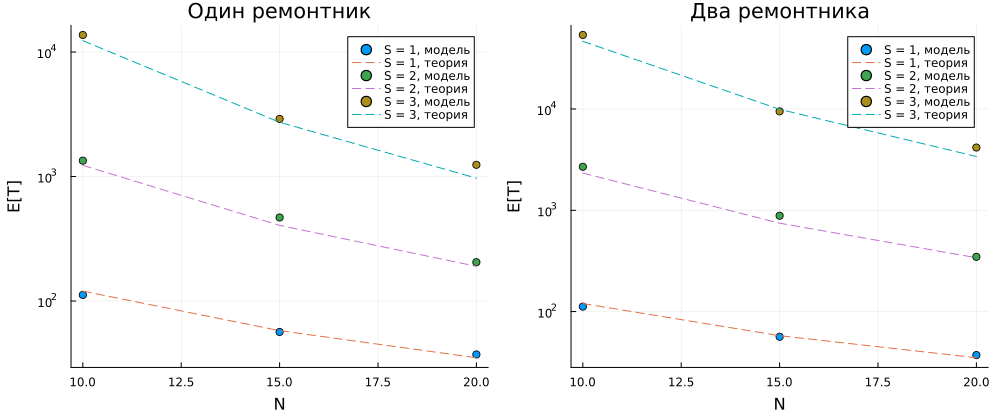

In [5]:
p1 = plot(xlabel = "N", ylabel = "E[T]", title = "Один ремонтник", yscale = :log10, legend = :topright)
p2 = plot(xlabel = "N", ylabel = "E[T]", title = "Два ремонтника", yscale = :log10, legend = :topright)
for s in sort(unique(df_ross.S))
    one = df_ross[(df_ross.S .== s) .& (df_ross.R .== 1), :]
    two = df_ross[(df_ross.S .== s) .& (df_ross.R .== 2), :]
    scatter!(p1, one.N, one.T_sim, label = "S = $s, модель")
    plot!(p1, one.N, one.T_theory, linestyle = :dash, label = "S = $s, теория")
    scatter!(p2, two.N, two.T_sim, label = "S = $s, модель")
    plot!(p2, two.N, two.T_theory, linestyle = :dash, label = "S = $s, теория")
end
plt_params = plot(p1, p2, layout = (1, 2), size = (1000, 420), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)

## Сохранение графика

In [6]:
savefig(plt_params, plotsdir("ross_params.png"))
println("Результаты сохранены в data/ross_params.csv и plots/ross_params.png")

Результаты сохранены в data/ross_params.csv и plots/ross_params.png
